# Function 8

<b> Description of the Sample Application:</b> You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.
For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this scor.




## Progress Log

| Week | Query Submitted (x1–x8) | Output (y) | Best y So Far | Acquisition / Strategy |
|---|---|---|---|---|
| Week 1 | 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351 | 9.888207 | 9.888207 | GP (RBF, fixed hyperparameters) + UCB (β=2.0), candidate search over 10,000-point Latin Hypercube — exploration-heavy |
| Week 2 | 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999 | 9.939383 | 9.939383 | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.5), next point via multi-start L-BFGS-B — shifting toward exploitation |
| Week 3 | - | - | - | GP (RBF, ARD, hyperparameters optimised) + UCB (β = 1.0), multi-start L-BFGS-B : further exploitation, since Week 2's query beat Week 1's and the GP's uncertainty has continued to shrink around the incumbent region |

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import qmc
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import (plot_2d_function, plot_2d_bo_state, plot_convergence, plot_parallel_coordinates)

# Load and Analyse the Data

In [15]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)




In [17]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.093998, 0.081832, 0.154891, 0.104133, 0.912141, 0.345036, 0.011181, 0.477351 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([9.8882074579574], dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.173855, 0.145601, 0.141754, 0.086242, 0.999999, 0.457141, 0.260715, 0.999999]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([9.9393827383054]                                                                  , dtype=np.float64)    # from output.txt


In [19]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                              ])

In [21]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [23]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated


# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

Input  Shape: (42, 8)
Inputs:
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59

In [25]:
# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df.head())

Data Frame:
         X_1       X_2       X_3       X_4       X_5       X_6       X_7  \
0  0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1  0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2  0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3  0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4  0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   

        X_8         Y  
0  0.734281  7.398721  
1  0.107132  7.005227  
2  0.367320  8.459482  
3  0.292472  8.284008  
4  0.593882  8.606117  


# Data Exploration

In [28]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  42.000000  42.000000  42.000000  42.000000  42.000000  42.000000   
mean    0.515529   0.455081   0.498463   0.414484   0.492147   0.457314   
std     0.315195   0.311860   0.286640   0.265070   0.293991   0.271108   
min     0.009077   0.003419   0.022929   0.009043   0.009649   0.022113   
25%     0.181665   0.151251   0.272628   0.155065   0.242101   0.247226   
50%     0.519375   0.503188   0.451130   0.438626   0.447599   0.409715   
75%     0.788620   0.688062   0.729167   0.656450   0.733288   0.693629   
max     0.985945   0.973980   0.998885   0.902986   0.999999   0.990244   

             X_7        X_8          Y  
count  42.000000  42.000000  42.000000  
mean    0.558089   0.517766   7.915204  
std     0.270483   0.284826   1.038932  
min     0.011181   0.041956   5.592193  
25%     0.335271   0.300059   7.302627  
50%     0.591723   0.525116   7.9408

In [30]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
X_7    0
X_8    0
Y      0
dtype: int64


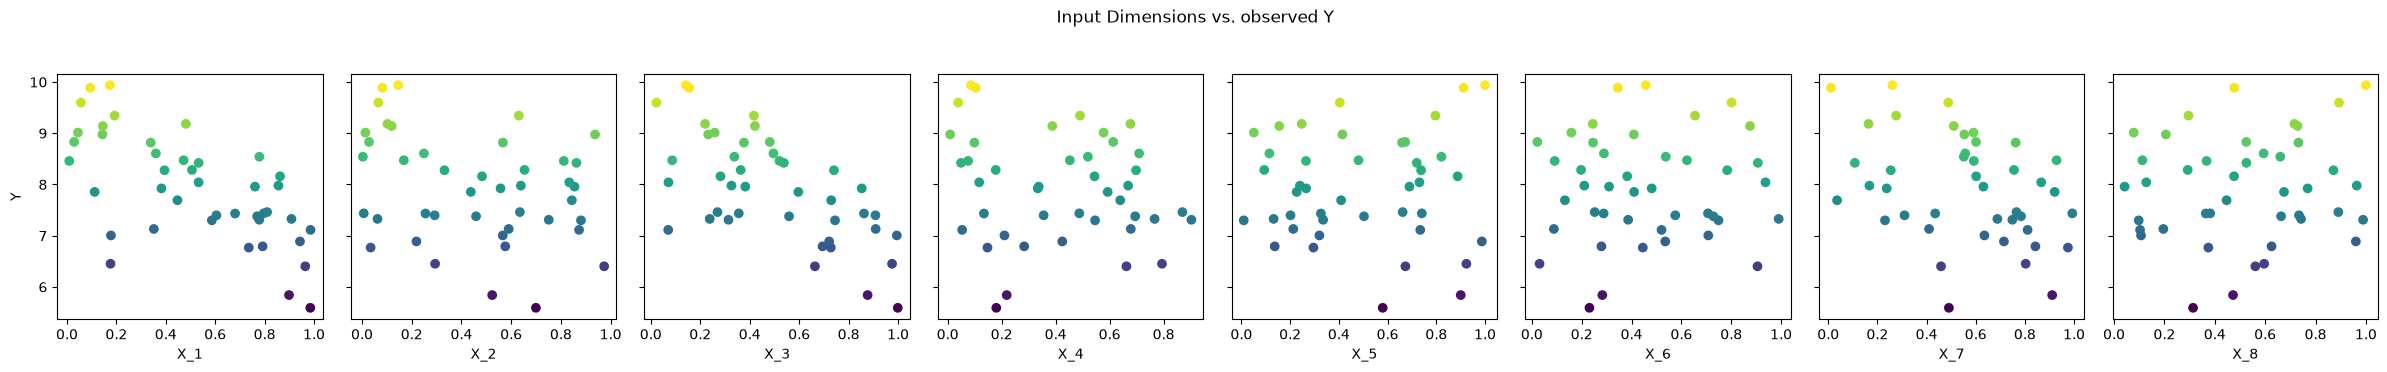

In [32]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6','X_7','X_8']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

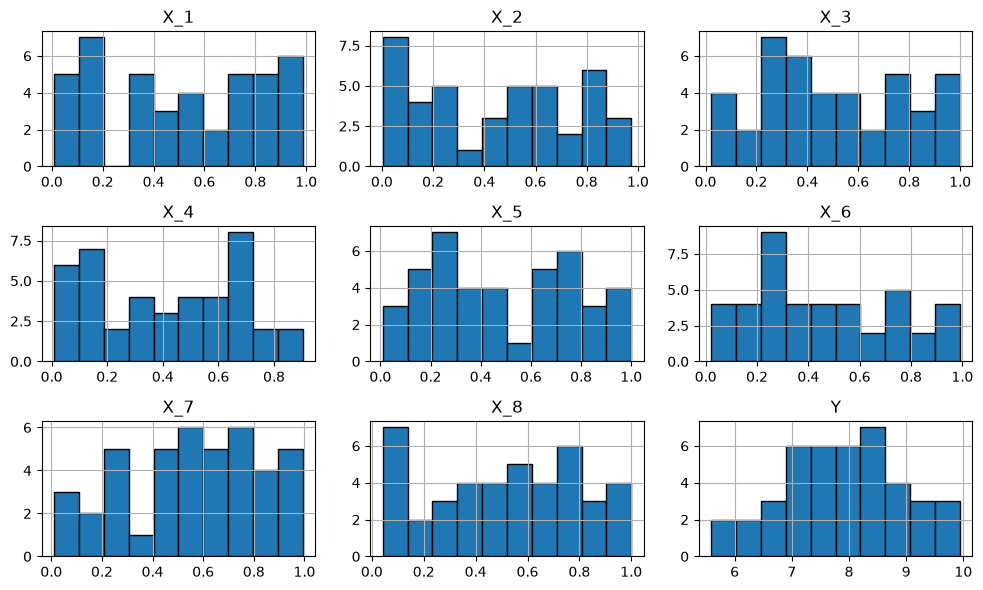

In [34]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [36]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", 'X_7','X_8']
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.6607692446500756
 corr(X_2, Y) = -0.3129399702642782
 corr(X_3, Y) = -0.6592764816495955
 corr(X_4, Y) = -0.18156175774653635
 corr(X_5, Y) = 0.013359635777203697
 corr(X_6, Y) = 0.04020405310020827
 corr(X_7, Y) = -0.3953987270500982
 corr(X_8, Y) = 0.12390831846911589


<Axes: >

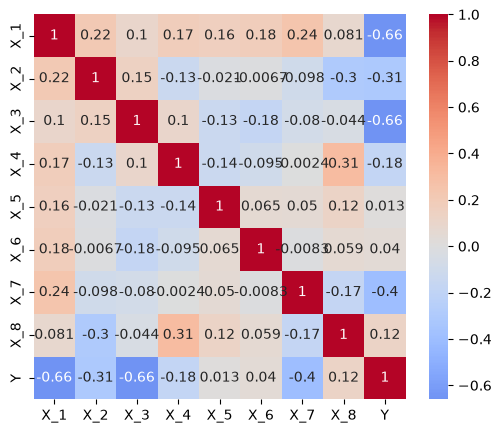

In [38]:
# Plotting the Correlation heatmap
plt.figure(figsize = (6,5))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

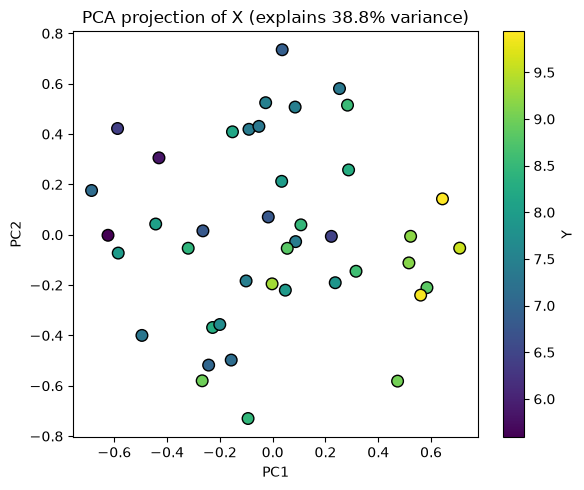

In [40]:
# Identify clustering of high-y points using PCA projection to 2D
pca  = PCA(n_components = 2)
X2   = pca.fit_transform(X)
plt.figure(figsize = (6, 5))
sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")
plt.colorbar(sc, label = "Y")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
plt.tight_layout()

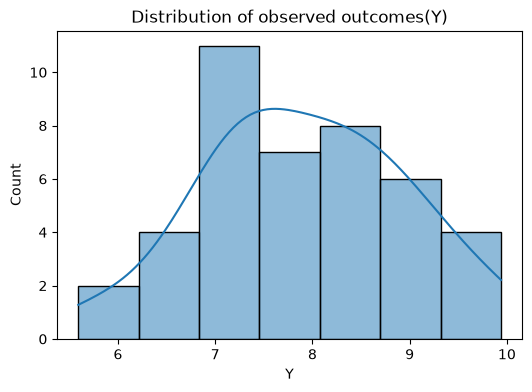

In [42]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [45]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-8, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [48]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.05**2 * RBF(length_scale=[1.74, 2.37, 1.34, 2.46, 3.45, 2.41, 1.81, 100]) + WhiteKernel(noise_level=1e-08)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [52]:
# Setting a higher beta(= 2.0) for Week -1
beta          = 2.0    # Week 1

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std   = gpr.predict(X_query, return_std = True)
    return mu + beta * std

n_points, n_dims = X.shape
rng_seed      = 42
n_candidates  = 10000
sampler       = qmc.LatinHypercube(d = n_dims, seed = rng_seed)
candidates    = sampler.random(n = n_candidates) 

ucb_values    = ucb(candidates, gpr, beta)
best_ucb_idx  = np.argmax(ucb_values)
next_point    = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.0367758  0.08940202 0.21038865 0.15722423 0.81773626 0.5591805
 0.10000647 0.84937986]
UCB Score: 1.000996e+01


# Week 2: Consolidated Bayesian Optimisation Function

In [55]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mu(x) + beta * sigma(x). Higher beta => more exploration."""
    return mu + beta * sigma
    
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best) - xi, 0)]."""
    with np.errstate(divide = "warn"):
        improvement = mu - y_best - xi
        Z           = improvement / sigma
        ei          = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def suggest_next_point( X_samples, y_samples, n_dims = 8, acquisition = "ucb", beta = 1.5,
                        xi = 0.01, n_restarts = 20, random_state = 42,
                        length_scale_bounds = (1e-2, 1e2), noise_bounds = (1e-8, 1e0)):

    rng    = np.random.default_rng(random_state)
    
    bounds = [(0.0, 0.999999)] * n_dims

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(n_dims), length_scale_bounds = length_scale_bounds) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = noise_bounds)
   
    gp     = GaussianProcessRegressor(kernel = kernel, normalize_y = False, n_restarts_optimizer = 10, random_state = random_state)
    
    gp.fit(X_samples, y_samples)

    y_best = y_samples.max()

    def acq_objective(x):
        x         = x.reshape(1, -1)    
        mu, sigma = gp.predict(x, return_std=True)
        
        if acquisition == "ei":
            val   = expected_improvement(mu, sigma, y_best, xi = xi)
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        
        return - val[0]  # minimise the negative -> maximise the acquisition

    best_val = np.inf
    X_next   = None
    for _ in range(n_restarts):
        x0   = rng.uniform(0, 0.999999, n_dims)
        res  = minimize(acq_objective, x0, bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            X_next   = res.x

    mu_next, sigma_next = gp.predict(X_next.reshape(1, -1), return_std = True)
    return X_next, gp, mu_next[0], sigma_next[0], - best_val


In [57]:
beta    = 1.5

X_next, gp_week2, mu_next, sigma_next, acq_val = suggest_next_point(  X, Y, n_dims = 8, acquisition = "ucb", 
                                                                      beta = beta, n_restarts = 20, random_state = 42
                                                                    )

print(f"Week 2 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean  : {mu_next:.4f}")
print(f"Predicted std   : {sigma_next:.4f}")
print(f"UCB acquisition : {acq_val:.4f}  (beta = {beta})")

Week 2 next query point: [0.134957 0.135179 0.205034 0.017629 0.672275 0.465545 0.187027 0.      ]
Predicted mean  : 9.9874
Predicted std   : 0.0386
UCB acquisition : 10.0453  (beta = 1.5)


# Week 3: Get Query Point

In [60]:
# lowered beta from 1.5 to 1.0
beta_week3 = 1.0  

X_next, gp_week3, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims = 8, acquisition = "ucb", beta = beta_week3, n_restarts = 20, random_state = 42
)

print(f"Week 3 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week3})")

Week 3 next query point: [0.13053  0.145043 0.199622 0.056929 0.701352 0.471131 0.191028 0.      ]
Predicted mean         : 9.9953
Predicted std          : 0.0323
UCB acquisition        : 10.0277  (beta = 1.0)


# Week 3: Perform Visualisation

In [63]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week3.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week3 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


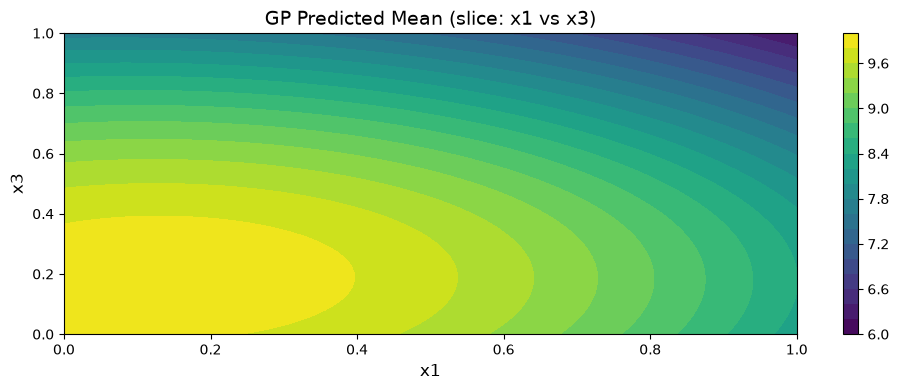

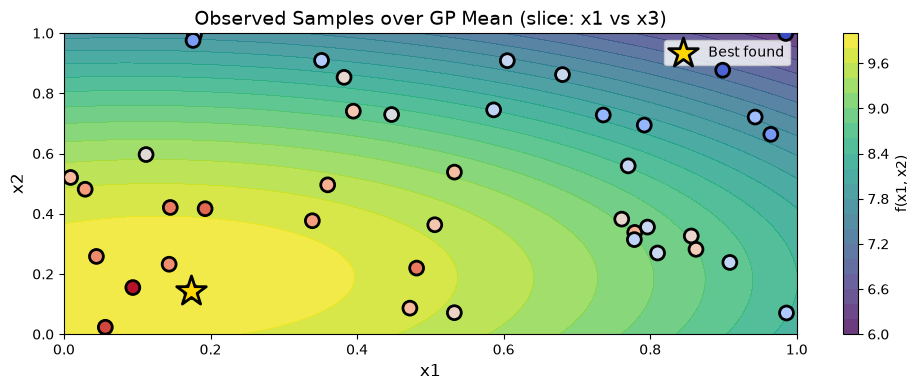

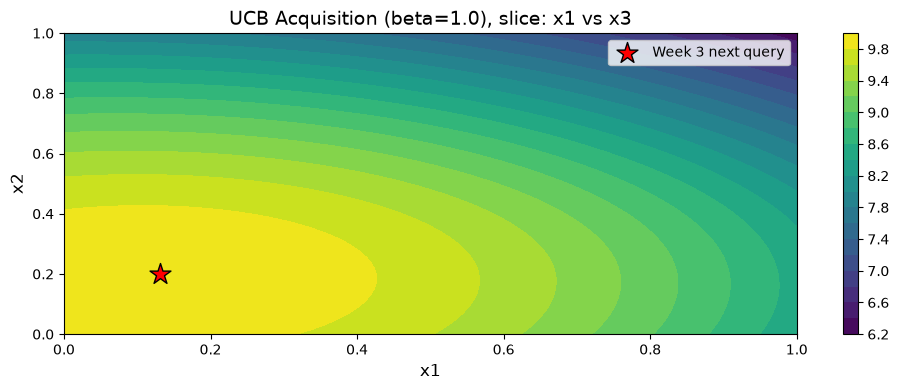

In [71]:
# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
plt.show()

# UCB acquisition surface with the Week 3 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week3}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 3 next query")
ax.legend()
plt.show()

# Portal Submission 

In [73]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(X_next)
print("Points to be submitted(Week 1):",'0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351')
print("Points to be submitted(Week 2):",'0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999')
print(f"Points to be submitted(Week 3): {submission_str}")

Points to be submitted(Week 1): 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351
Points to be submitted(Week 2): 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999
Points to be submitted(Week 3): 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000
